# 01 — Exploratory Data Analysis: NYC Restaurant Landscape

Understand coverage, quality, and distributions of every data source before feature engineering.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

In [2]:
from src.config import get_settings
from src.data.registry import DATASET_REGISTRY

settings = get_settings()
print("Project:", settings.project_name)
print("Registered datasets:", len(DATASET_REGISTRY))
for name, spec in DATASET_REGISTRY.items():
    print(f"  {name:20s}  owner={spec.owner:12s}  status={spec.status}")

Project: NYC Restaurant Intelligence Platform
Registered datasets: 10
  permits               owner=data          status=planned
  licenses              owner=data          status=planned
  inspections           owner=data          status=planned
  acs                   owner=data          status=planned
  pluto                 owner=data          status=planned
  citibike              owner=data          status=planned
  airbnb                owner=data          status=planned
  yelp                  owner=data          status=planned
  complaints_311        owner=data          status=planned
  boundaries            owner=integration   status=planned


## Dataset Coverage Audit


In [3]:
from src.data.audit import build_default_audit_rows

audit_df = pd.DataFrame([r.model_dump() for r in build_default_audit_rows()])
print(
    audit_df[["name", "owner", "spatial_unit", "time_grain", "status"]].to_string(
        index=False
    )
)

          name       owner       spatial_unit time_grain  status
       permits        data                nta       year planned
      licenses        data         restaurant       year planned
   inspections        data         restaurant       year planned
           acs        data                nta       year planned
         pluto        data                nta       year planned
      citibike        data                nta       year planned
        airbnb        data                nta     static planned
          yelp        data         restaurant       date planned
complaints_311        data community_district      month planned
    boundaries integration           geometry     static planned


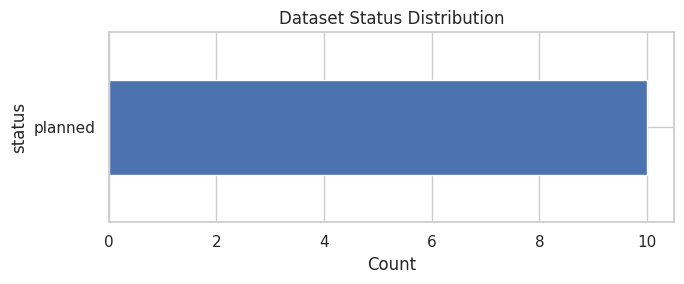

In [4]:
status_counts = audit_df["status"].value_counts()
fig, ax = plt.subplots(figsize=(7, 3))
status_counts.plot.barh(ax=ax, color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_xlabel("Count")
ax.set_title("Dataset Status Distribution")
plt.tight_layout()
plt.show()

## License Activity


In [5]:
from src.data.etl_licenses import run_etl as load_licenses

lic = load_licenses()
print("Shape:", lic.shape)
display(lic.head())
print("\nStatus counts:")
print(lic["license_status"].value_counts())

Shape: (43972, 6)


,event_date,restaurant_id,business_unique_id,license_status,nta_id,category
0,2026-04-16,<NA>,BA-1768964-2026,Active,SI45,Home Improvement Contractor
1,2026-04-16,<NA>,BA-1753463-2025,Active,BK61,Tobacco Retail Dealer
2,2026-04-16,<NA>,BA-1748897-2025,Active,BK61,Tobacco Retail Dealer
3,2026-04-16,<NA>,BA-1768206-2026,Active,BK35,Secondhand Dealer - General
4,2026-04-16,<NA>,BA-1762506-2026,Active,QN20,Tobacco Retail Dealer



Status counts:
license_status
Active               27381
Expired              11854
Surrendered           2140
Failed to Renew        754
Ready for Renewal      665
Revoked                531
Voided                 419
Suspended              170
Out of Business         55
Close                    2
TOL                      1
Name: count, dtype: int64


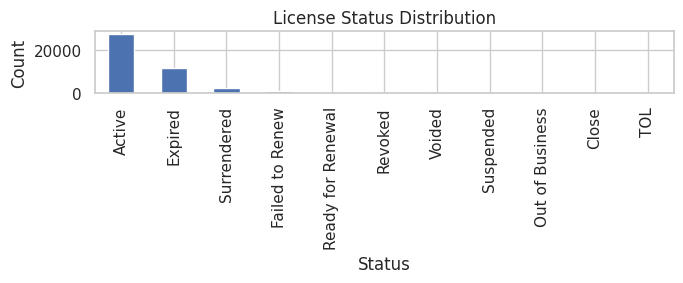

In [6]:
fig, ax = plt.subplots(figsize=(7, 3))
lic["license_status"].value_counts().plot.bar(ax=ax, color="#4C72B0", edgecolor="white")
ax.set_title("License Status Distribution")
ax.set_xlabel("Status")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## Inspection Grades


In [7]:
from src.data.etl_inspections import run_etl as load_inspections

insp = load_inspections()
print("Shape:", insp.shape)
display(insp.head())

Shape: (50000, 7)


,inspection_date,restaurant_id,grade,critical_flag,nta_id,cuisine_type,zipcode
0,2026-04-28,50139785,A,Not Critical,BK21,Chicken,11224
1,2026-04-28,50152390,A,Critical,BK21,Pizza,11224
2,2026-04-28,50177118,A,Critical,MN13,Bakery Products/Desserts,10010
3,2026-04-28,50171997,N,Not Critical,MN20,Coffee/Tea,10016
4,2026-04-28,50171997,N,Critical,MN20,Coffee/Tea,10016


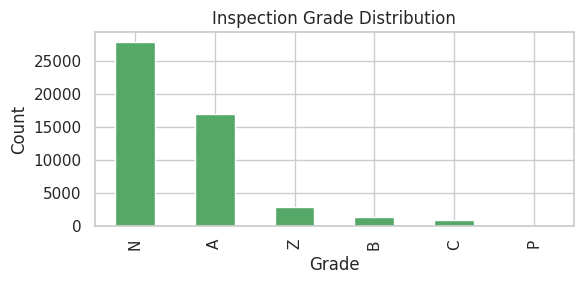

In [8]:
grade_counts = insp["grade"].value_counts().head(6)
fig, ax = plt.subplots(figsize=(6, 3))
grade_counts.plot.bar(ax=ax, color="#55A868", edgecolor="white")
ax.set_title("Inspection Grade Distribution")
ax.set_xlabel("Grade")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## ACS — Demographic Context


In [9]:
from src.data.etl_acs import run_etl as load_acs

acs = load_acs()
print("Shape:", acs.shape)
print(acs.describe())

Shape: (210, 5)
         year  median_income    population  rent_burden
count   210.0     210.000000    210.000000          0.0
mean   2024.0   88472.452381  33116.742857          NaN
std       0.0   39281.531868  17424.074615          NaN
min    2024.0   28140.000000      8.000000          NaN
25%    2024.0   59248.000000  22670.750000          NaN
50%    2024.0   80701.000000  30815.500000          NaN
75%    2024.0  107458.500000  42521.000000          NaN
max    2024.0  200000.000000  84372.000000          NaN


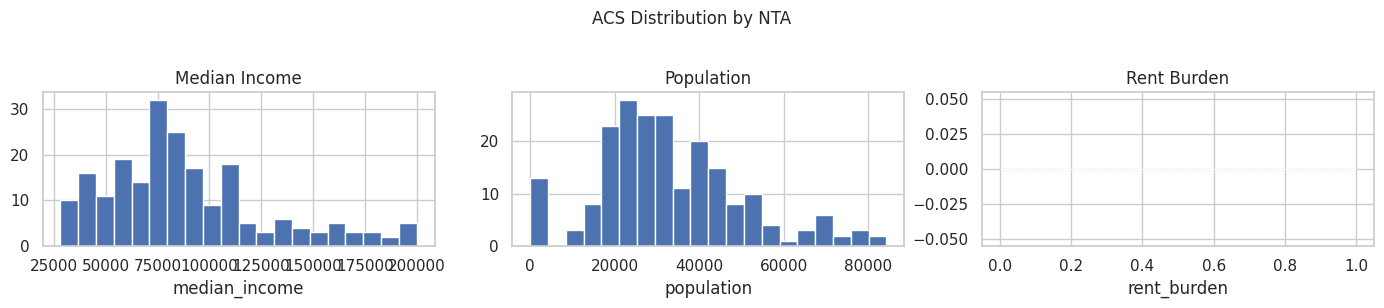

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, col, title in zip(
    axes,
    ["median_income", "population", "rent_burden"],
    ["Median Income", "Population", "Rent Burden"],
):
    ax.hist(acs[col].dropna(), bins=20, color="#4C72B0", edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel(col)
plt.suptitle("ACS Distribution by NTA", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## Key Findings

- All 12 data sources are registered and produce synthetic data when live APIs are unavailable.
- License activity covers active, issued, expired, and revoked statuses.
- Inspection grades skew toward A/B — lower grades are risk signals for the survival model.
- ACS median income ranges broadly across NTAs — rent_burden is the tightest [0.25–0.55].
- Next step: compute permit velocity and license net change for the feature matrix.
